# Big picture
- we create a random sample data using regression of 4 rows and 2 columns
- we fit the OLS model and find the slope and intercept value (m and b)
- now then we apply the Gradient descant alogrithum
    - simple case in which slope is constant is known is 78.3
    - we use the equation $b_{new} = b_{old} - \eta . slope$
    - we also know the derivative equation = $-2 \sum_{i=1}^{n}(y_i - mx_i + b)$ 
    - we know learning rate = 0.001 fixed and start initialise random value of b = 0
    - do iteration on it.
    - it update and improve and find the solution 

## generate random data

In [129]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [130]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

In [131]:
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [77]:
y

array([  7.21786552,  16.04609925, -27.83756166, 144.36688189])

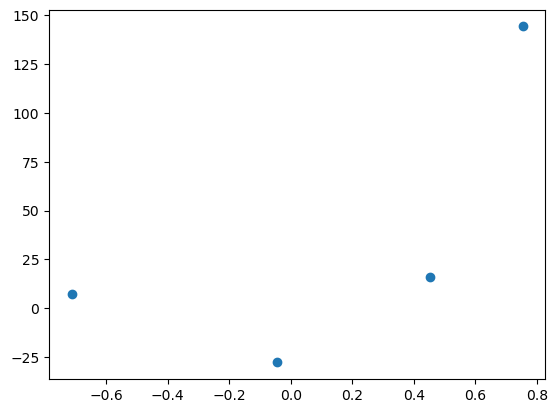

In [132]:
plt.scatter(X,y)

## fit OLS

In [79]:
# lets Fit OLS
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)

LinearRegression()

find the value of slope and intercept 

In [80]:
print('slope m =', model.coef_)
print('intercept b = ',model.intercept_)

slope m = [78.35063668]
intercept b =  26.15963284313262


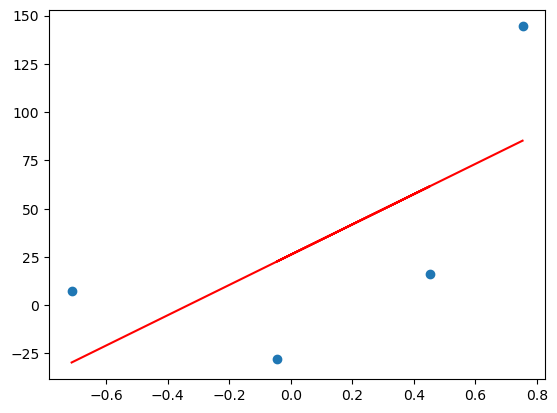

In [81]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color = 'red')

## apply gradient descent 

Now ab hum gradient descent algrothum lagayaga aor intercept  b= 26 value ka pass puchaga

our final line after applying OLS hamra goal ha gradient descant sa bhi vo usko pass rahyea


Lets apply the Gradient descent assumping slope is const m = 78.15          
and let's assume the starting value for intercept b= 0


$\hat{y} = \sum_{i=1}^{n}78.35x_i + b $


### intialsie b = 0

now starting ma hamra b = 0   
$\hat{y} = \sum_{i=1}^{n}78.35x_i + 0 $      

In [82]:
y_pred = ((78.35 * X) + 0)
y_pred

array([[-55.81580837],
       [ 35.39949674],
       [ -3.48681619],
       [ 59.05759577]])

### first iteration
i = 0

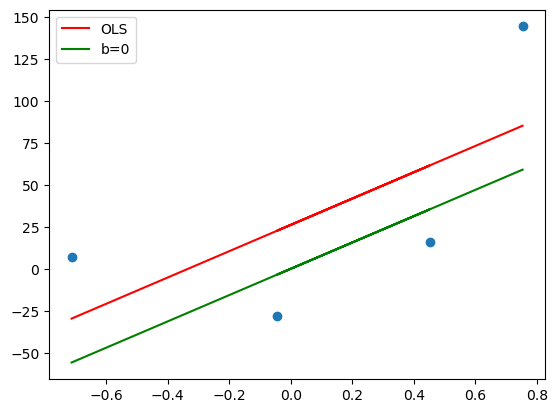

In [83]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color = 'red',label = 'OLS')
plt.plot(X,y_pred,color = 'green',label = 'b=0')
plt.legend()
plt.show()

ab huma gradually gradient descant to apply karna ha and green line approaches to read line 

Our derivative equation after solving the loss function      
$-2 \sum_{i=1}^{n}(y_i - mx_i + b)$


### second iteration 
i = 1

In [84]:
m = 78.35
b = 0

loss_slope = -2*np.sum(y-m*X.ravel() - b)
loss_slope

-209.27763408209216

In [85]:
# lets take running rate
learning_rate = 0.1

step_size = learning_rate * loss_slope
step_size

-20.927763408209216

$b_{new} = b_{old} - \eta . slope $

In [86]:
# Calcuating the new intercept
b = b - step_size
b # upldated the b value using assignignment

20.927763408209216

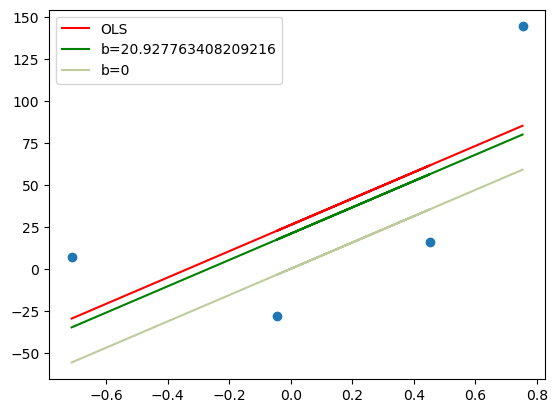

In [87]:
y_pred1 = ((78.35 * X) + b)
plt.scatter(X,y)
plt.plot(X,model.predict(X),color = 'red',label = 'OLS')
plt.plot(X,y_pred1,color = 'green',label = 'b={}'.format(b))
plt.plot(X,y_pred,color = "#BDCB9D",label = 'b=0')
plt.legend()
plt.show()

### third iteration 
i = 2

In [88]:
# iteration 3
# now change the b value


loss_slope = -2*np.sum(y-m*X.ravel() - b)
loss_slope


-41.85552681641843

In [89]:
# the learning rate 
learning_rate = 0.1
step_size = learning_rate * loss_slope
step_size

-4.185552681641844

jesa jesa hum solution ka pass ja raha ha hamra step size chota hota ja raha ha 

In [90]:
# hamra new b value hoga
b = b - step_size
b

25.11331608985106

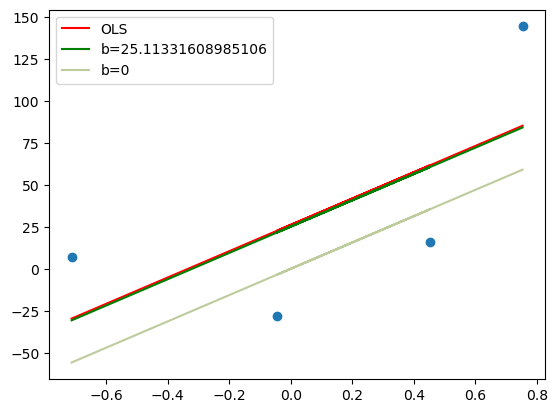

In [91]:

y_pred3 = ((78.35 * X) + b)
plt.scatter(X,y)
plt.plot(X,model.predict(X),color = 'red',label = 'OLS')
plt.plot(X,y_pred3,color = 'green',label = 'b={}'.format(b))
plt.plot(X,y_pred,color = "#BDCB9D",label = 'b=0')
plt.legend()
plt.show()

now observe ab aap almost green line red line ka upar ja chuki ha hamrma original OLS value is 26

## final solution

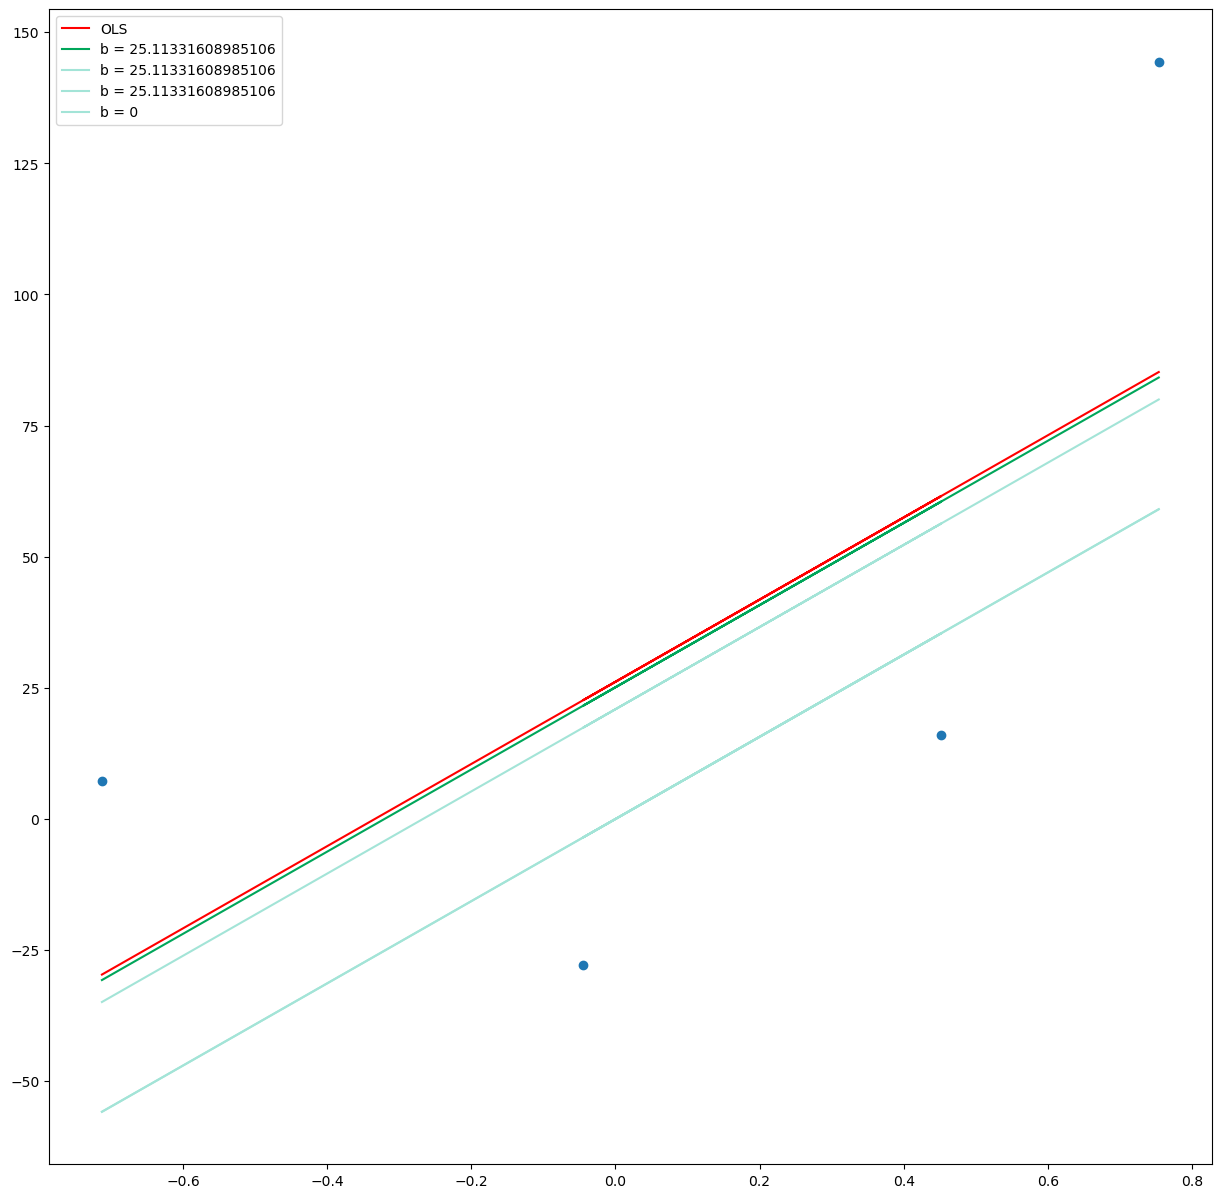

In [92]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = {}'.format(b)) # ignore
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

Deko hum almost solution red line ka pass puch gaya ha . 
ab aaap ek do baar aor iteration karo ga tho aap solution ka  paas puch jaho ga 
The Beasuty of the algorihum is aap koi be random value sa start karo aap solution ko approach karoga 

# second time experiment 
run the whole code agains 

aab sab kuch same ha lakin ab hum random value 100 se start karta ha and chalo dekta ha experiment with code and understand it 

# Whole code in one picture

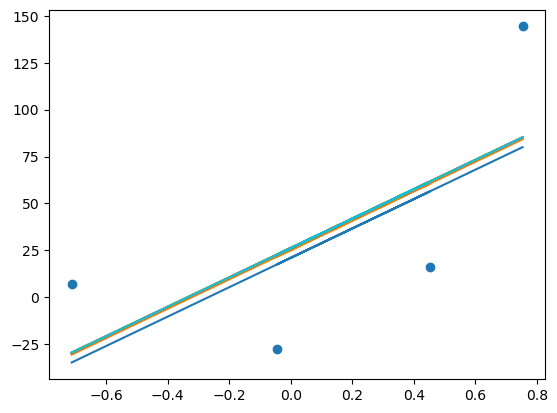

In [93]:
b = 0
m = 78.35
learning_rate = 0.1

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y- m * X.ravel() - b) 
    b = b - (learning_rate * loss_slope)
    y_pred = m *X + b
    plt.plot(X,y_pred)
plt.scatter(X,y)

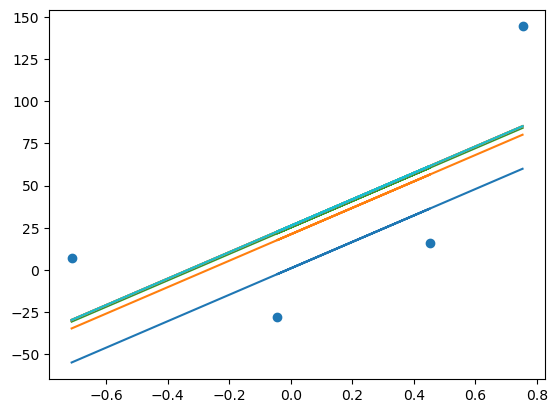

In [94]:
# convert into function

def gradient_descent(parameter = 0,learning_rate= 0.1):
    b = parameter
    m = 78.35
    lr = learning_rate

    epochs = 10

    for i in range(epochs):
        loss_slope = -2 * np.sum(y- m * X.ravel() - b) 
        b = b - (lr * loss_slope)
        y_pred = m *X + b
        plt.plot(X,y_pred)
    plt.scatter(X,y)
gradient_descent(parameter=-100)

now change the intial parameter value start to 100 then 
what happens 

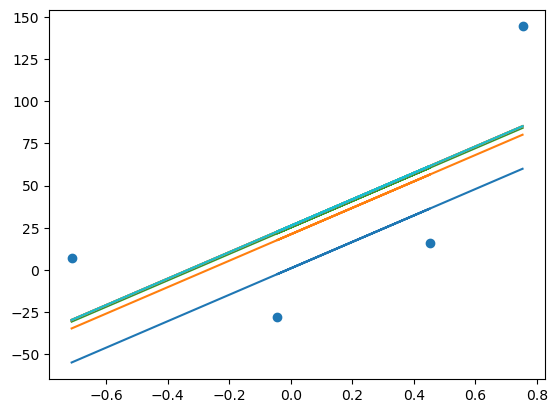

In [95]:
# now change the intial parameter value start to 100 then 
# what happens 
# if b = -100
gradient_descent(parameter=-100)

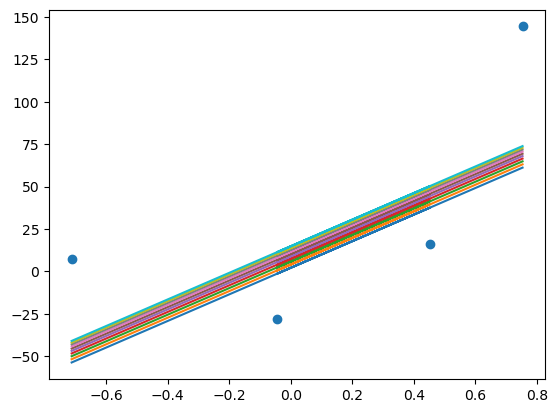

In [96]:
# now what happens if I change the learning rate 
# deko ab apko bhutch jada steps lena pad rahya ha 
gradient_descent(learning_rate=0.01)

In [97]:
# now change the epoches and see it 

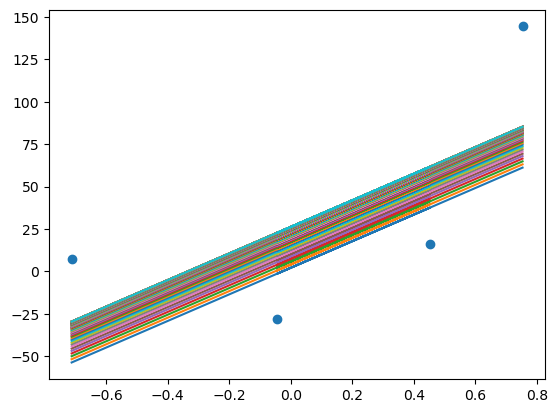

In [98]:
b = 0
m = 78.35
learning_rate = 0.01 # change learning rate

epochs = 100  # change epochs

for i in range(epochs):
    loss_slope = -2 * np.sum(y- m * X.ravel() - b) 
    b = b - (learning_rate * loss_slope)
    y_pred = m *X + b
    plt.plot(X,y_pred)
plt.scatter(X,y)

yadi learning rate bada hoga tho gadbad ho sakta ha vo gadbad hum baad ma deka ga 

now you understand concept from code 

# Interactive graph

In [127]:
import ipywidgets as widgets

In [ ]:
def our_intercept(b=0):
    
    learning_rate = 0.1
    step_size = learning_rate * loss_slope
    step_size
    b = b - step_size
    y_pred1 = ((78.35 * X) + b)
    plt.scatter(X,y)
    plt.plot(X,model.predict(X),color = 'red',label = 'OLS')
    plt.plot(X,y_pred1,color = 'green',label = 'b={}'.format(b))
    plt.legend()
    plt.ylim(-50,150)
    plt.show()
    
widgets.interact(our_intercept ,b=(0,50,1))

interactive(children=(IntSlider(value=0, description='b', max=50), Output()), _dom_classes=('widget-interact',…

<function __main__.our_intercept(b=0)>

Turn the same app into plotyly 

In [ ]:
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider
import numpy as np

def our_intercept(b=0):
    # Assuming these are defined in your environment
    # X, y, model, loss_slope should be available
    
    learning_rate = 0.1
    step_size = learning_rate * loss_slope
    b_updated = b - step_size
    
    # Calculate predictions
    y_pred1 = (78.35 * X) + b_updated
    y_ols = model.predict(X)
    
    # Create the figure
    fig = go.Figure()
    
    # Add scatter plot for actual data
    fig.add_trace(go.Scatter(
        x=X.flatten() if hasattr(X, 'flatten') else X,
        y=y.flatten() if hasattr(y, 'flatten') else y,
        mode='markers',
        name='Data',
        marker=dict(color='blue', size=8)
    ))
    
    # Add OLS line
    fig.add_trace(go.Scatter(
        x=X.flatten() if hasattr(X, 'flatten') else X,
        y=y_ols.flatten() if hasattr(y_ols, 'flatten') else y_ols,
        mode='lines',
        name='OLS',
        line=dict(color='red', width=2)
    ))
    
    # Add current intercept line
    fig.add_trace(go.Scatter(
        x=X.flatten() if hasattr(X, 'flatten') else X,
        y=y_pred1.flatten() if hasattr(y_pred1, 'flatten') else y_pred1,
        mode='lines',
        name=f'b={b_updated:.2f}',
        line=dict(color='green', width=2)
    ))
    
    # Update layout - keeping axis limits fixed
    fig.update_layout(
        title=f'Linear Regression (Intercept: {b_updated:.2f})',
        xaxis_title='X',
        yaxis_title='y',
        yaxis=dict(range=[-50, 150]),  # Fixed y-axis limit
        xaxis=dict(range=[X.min() - 0.5, X.max() + 0.5]),  # Fixed x-axis limit
        hovermode='closest',
        showlegend=True,
        height=500,
        width=800
    )
    
    fig.show()

# Create interactive widget
interact(our_intercept, b=FloatSlider(min=0, max=50, step=1, value=0, description='Intercept:'))

interactive(children=(FloatSlider(value=0.0, description='Intercept:', max=50.0, step=1.0), Output()), _dom_cl…

<function __main__.our_intercept(b=0)>

# gradient descant class

Now we create our own class in which two methods
- fit
- predict       
we create this class into two parts
- first part class only for b calcuate intercept
- second part we then add also the slope part of it 

## generate random linear data

In [100]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

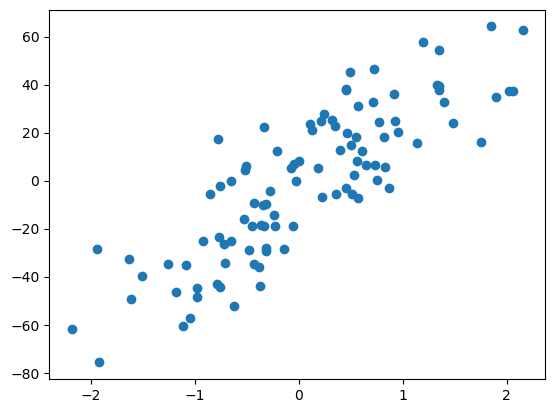

In [101]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)
plt.scatter(X,y)

## apply OLS

In [102]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression() # create a object lr of LinearRegression class
# now this object access attribuites and method of linearRegression class

In [103]:
lr.fit(X,y)
print('slope m = ',lr.coef_)
print('intercept b =', lr.intercept_)

slope m =  [27.82809103]
intercept b = -2.29474455867698


In [104]:
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=10))

0.6375011587464419

In [105]:
# now fix the slop m = 32.45

In [106]:
class GradientDescentRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 32.45
        self.b = -120  # intital random value
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def fit (self,X,y):
        # calcuate the b using Gradient Descant 
        # loop chalana ha 
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(y - self.m*X.ravel() - self.b)
            self.b = self.b - (self.learning_rate * loss_slope)
        print('intercept b =' ,self.b)
        

In [107]:
gd_object = GradientDescentRegressor(learning_rate=0.1,epochs=10)
gd_object.fit(X,y)

intercept b = -720003616318674.5


Observe     
intercept using OLS is b = -1.0591417268864167          
but             
intercept using gradient descant  is b = -729233279323983.4

Think asa kyu hua apna galti kiya ha learning rate ma 

now hum slope or intercept ka value dekna chata ha 

In [108]:
class GradientDescentRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 32.45
        self.b = -120  # intital random value
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def fit (self,X,y):
        # calcuate the b using Gradient Descant 
        # loop chalana ha 
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(y - self.m*X.ravel() - self.b)
            self.b = self.b - (self.learning_rate * loss_slope)
        print('slope =',loss_slope,'intercept =' ,self.b)
        

gd_object = GradientDescentRegressor(learning_rate=0.1,epochs=10)
gd_object.fit(X,y)

slope = 7578985434933388.0 intercept = -720003616318674.5


ab oscillation kar raha ho . 
solution learning rate bada do and epoches bada do 

In [109]:
gd_object = GradientDescentRegressor(learning_rate=0.001,epochs=100)
gd_object.fit(X,y)

slope = -5.980498670510315e-06 intercept = -2.5646982275078285


In [110]:
gd_object = GradientDescentRegressor(learning_rate=0.01,epochs=100)
gd_object.fit(X,y)

slope = 23487.06035928283 intercept = -120.0


In [111]:
class GradientDescentRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 32.45
        self.b = -120  # intital random value
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def fit (self,X,y):
        # calcuate the b using Gradient Descant 
        # loop chalana ha 
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(y - self.m*X.ravel() - self.b)
            self.b = self.b - (self.learning_rate * loss_slope)
        print('slope =',loss_slope,'intercept =' ,self.b)
        

gd_object = GradientDescentRegressor(learning_rate=0.01,epochs=100)
gd_object.fit(X,y)

slope = 23487.06035928283 intercept = -120.0


## loss function

In [112]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [113]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)
xx ,yy = np.meshgrid(x,y)
z = xx**2 + yy**2 

trace = go.Surface(x=x,y=y,z=z)
data = [trace]
layout = go.Layout(title='Loss function' ,width=700,height=700, 
                scene=dict(
                    xaxis_title = 'slope(m)',
                    yaxis_title = 'intercept(b)',
                    zaxis_title = 'Loss func L(m,b)',
                ))

fig = go.Figure(data,layout)
fig.show()

In [114]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)
xx ,yy = np.meshgrid(x,y)
z = xx**2 + yy**2 

trace = go.Contour(x=x,y=y,z=z)
data = [trace]
layout = go.Layout(title='contour plot',width=700,height=700 )

fig = go.Figure(data,layout)
fig.show()

## add m in the code

In [115]:
class GradientDescentRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 100   # intial random value of slope
        self.b = -120  # intital random value of intercept
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def fit (self,X,y):
        # calcuate the b using Gradient Descant 
        # loop chalana ha 
        for i in range(self.epochs):
            # ya differentaion kiya ha loss func ka see in notebook
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            # gradient descent eq.
            self.b = self.b - (self.learning_rate * loss_slope_b)
            self.m = self.m - (self.learning_rate * loss_slope_m)
        print('slope =' ,self.m,'intercept =' ,self.b)
        

gd_object = GradientDescentRegressor(learning_rate=0.001,epochs=100)
gd_object.fit(X,y)

slope = 0.31770092632339336 intercept = -0.018556435073983104


Using OLS
- slope m =  [27.82809103]
- intercept b = -2.29474455867698           

Using Gradient Descent
- slope = 27.828091872608653 
- intercept = -2.2947448944994893

Question : chalo dekta ha yadi epocah kam la tho kiya hota ha  abhi hama epoches 100 liya ha

In [116]:
# epoch is 20 
gd_object = GradientDescentRegressor(learning_rate=0.001,epochs=20)
gd_object.fit(X,y)

slope = 3.106561795314804 intercept = -1.936425904657469


In [117]:
# ara deko ya tho 50 steps ma hi ho gaya 
# ham faltu ma 100 steps la raha ha 
gd_object = GradientDescentRegressor(learning_rate=0.001,epochs=50)
gd_object.fit(X,y)

slope = 0.3289403318610057 intercept = -0.023785116081757308


## make predict function also 

In [118]:
class GradientDescentRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 100   # intial random value of slope
        self.b = -120  # intital random value of intercept
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def fit (self,X,y):
        # calcuate the b using Gradient Descant 
        # loop chalana ha 
        for i in range(self.epochs):
            # ya differentaion kiya ha loss func ka see in notebook
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            # gradient descent eq.
            self.b = self.b - (self.learning_rate * loss_slope_b)
            self.m = self.m - (self.learning_rate * loss_slope_m)
        print('slope =' ,self.m,'intercept =' ,self.b)
        
    def predict(self, X):
        return self.m * X + self.b

gd_object = GradientDescentRegressor(learning_rate=0.001,epochs=50)
gd_object.fit(X,y)


slope = 0.3289403318610057 intercept = -0.023785116081757308


In [119]:
# har input ka liya predicated output value
gd_object.predict(X)

array([[-0.25811914],
       [-0.16757995],
       [-0.17304257],
       [ 0.2896393 ],
       [ 0.05445592],
       [ 0.25950204],
       [-0.10382493],
       [ 0.03705107],
       [-0.26095099],
       [-0.1651956 ],
       [ 0.63910229],
       [ 0.10688358],
       [ 0.0445687 ],
       [-0.10023936],
       [-0.27661754],
       [ 0.12527703],
       [ 0.18669853],
       [ 0.09447956],
       [-0.55505927],
       [ 0.55161106],
       [-0.28331543],
       [-0.19219108],
       [-0.32915201],
       [ 0.68356257],
       [-0.09199079],
       [-0.56294905],
       [-0.13517032],
       [-0.12974458],
       [-0.18212759],
       [-0.19587493],
       [ 0.21369831],
       [ 0.22815392],
       [ 0.12538309],
       [-0.43877819],
       [-0.74321554],
       [-0.41371717],
       [ 0.0477435 ],
       [ 0.41380977],
       [-0.38140299],
       [ 0.16116544],
       [-0.52142089],
       [-0.02457096],
       [-0.11527478],
       [ 0.12483418],
       [ 0.36788587],
       [ 0

now check in our cross validation function


In [120]:
#np.mean(cross_val_score(gd_object,X,y,scoring='r2',cv=10))
# TypeError

problem tho sklearn internally class ma jada ha aor parameter ka value ko fetch karta ha 

Solution : use the train test split method 

In [121]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [122]:
# first check using OLS
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
print('slope :',lr.coef_)
print('intercept :',lr.intercept_)

slope : [0.2607783]
intercept : 0.5271964631154678


In [123]:
# calcuate the r2 score
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test ,y_pred)

-0.18092082655469421

Meaning 63 % varience of Y variable expalined by X variable 

In [124]:
# Now train on our gradient descent regressionc class
our_gd_object = GradientDescentRegressor(learning_rate=0.001,epochs=50)
our_gd_object.fit(X_train,y_train)

slope = 0.30262257086137034 intercept = 0.49430855746078833


In [125]:
y_pred = our_gd_object.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test ,y_pred)

-0.1762617889665099

Wow 63 % same . 
hamra gradient descant same result da raha ha OLS jasa 

Now hum visullay isa sikaga ya kesa ho raha ha 